# Un descubrimiento empírico: el valor de contar es un fenómeno de horizonte

**La pregunta.** No "¿cuánto vale contar?" sino "¿de qué depende?". Buscamos una
regularidad no obvia en cómo se comporta el algoritmo, no una descripción.

**El hallazgo, en una frase.** El beneficio del conteo $U^D_A - U^D$ lo gobierna el
**horizonte de tests $B$**, no el tamaño de pool $G$ ni realmente la población $N$.
Es **exactamente cero con $B=1$** y crece con $B$; $G$ apenas mueve la aguja y
satura pronto. Eso reencuadra el "crece con la escala" del borrador en algo más
afilado y correcto: crece con el **horizonte**.

**Cómo se obtuvo.** Cinco probes empíricos en paralelo (prevalencia, horizonte,
greedy-gap, cosecha, utilidad), cada uno corriendo DP exacto sobre cientos de
instancias, con verificación adversarial de los más fuertes (semillas y escala
nuevas). El barrido reproducible vive en `horizon_experiment.py`; aquí se carga su
CSV y se confirma en vivo el núcleo del hallazgo.


In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import augmented
ROOT = os.path.dirname(os.path.dirname(os.path.abspath(augmented.__file__)))
from augmented.solver import solve_optimal_dapts            # U_D_A (augmented)
from augmented.classical_solver import solve_classical_dynamic  # U_D (binario)
df = pd.read_csv(os.path.join(ROOT, 'results/horizon/horizon_sweep.csv'))
print('barrido cargado:', len(df), 'puntos | ejes:', sorted(df.axis.unique()))

barrido cargado: 15 puntos | ejes: ['B', 'G', 'N', 'U']


## 1. El núcleo, en vivo: con $B=1$ el beneficio es exactamente cero

La predicción más fuerte y más fácil de verificar: si solo hay un test, contar no
puede aportar nada sobre el binario. Con un solo test, la utilidad inmediata
(limpiar un pool con conteo 0) es idéntica en ambos esquemas, y no hay un test
futuro al que un posterior más afilado pueda ayudar. Así que $U^D_A = U^D$ en TODA
instancia con $B=1$.

In [2]:
rng = np.random.default_rng(11)
iguales = 0
for _ in range(25):
    p = rng.uniform(0, 1, size=6).tolist()
    u = rng.choice([1., 2., 3.], size=6).tolist()
    uda = solve_optimal_dapts(p, u, 1, 5)[0]
    ud = solve_classical_dynamic(p, u, 1, 5)[0]
    if abs(uda - ud) < 1e-9:
        iguales += 1
print(f'B=1:  U_D_A == U_D en {iguales}/25 instancias  ->  beneficio exactamente 0')

B=1:  U_D_A == U_D en 25/25 instancias  ->  beneficio exactamente 0


## 2. El barrido: B domina, G satura, N importa menos

Aislamos cada eje. La curva de $B$ arranca en cero y sube; la de $G$ es casi plana
y satura; la de $N$ sube, pero menos que $B$. El span (cuánto mueve cada eje el
beneficio medio) lo deja claro de un vistazo.

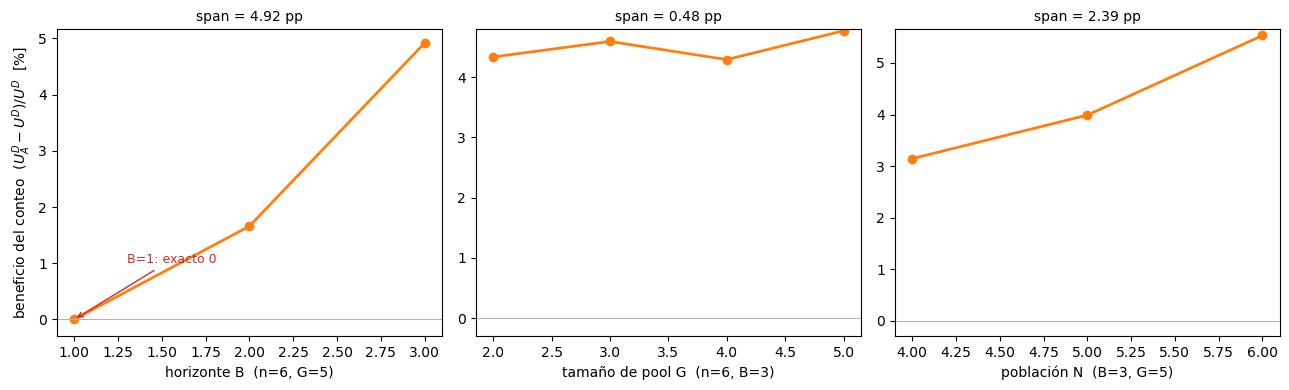

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, axis, xcol, xlabel in [
        (axes[0], 'B', 'B', 'horizonte B  (n=6, G=5)'),
        (axes[1], 'G', 'G', 'tamaño de pool G  (n=6, B=3)'),
        (axes[2], 'N', 'N', 'población N  (B=3, G=5)')]:
    d = df[df.axis == axis].sort_values(xcol)
    ax.plot(d[xcol], d['rel_mean'], 'o-', color='tab:orange', lw=2)
    ax.set_xlabel(xlabel); ax.set_ylim(bottom=-0.3)
    ax.axhline(0, color='0.7', lw=0.8)
    ax.set_title(f'span = {d.rel_mean.max() - d.rel_mean.min():.2f} pp', fontsize=10)
axes[0].set_ylabel(r'beneficio del conteo  $(U^D_A-U^D)/U^D$  [%]')
axes[0].annotate('B=1: exacto 0', xy=(1, 0), xytext=(1.3, 1.0), fontsize=9,
                 color='tab:red', arrowprops=dict(arrowstyle='->', color='tab:red'))
plt.tight_layout(); plt.show()

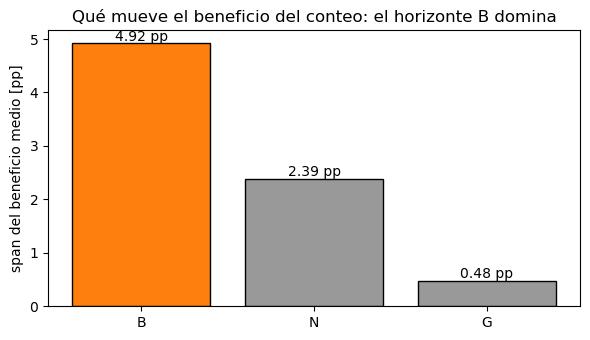

spans (pp): {'B': 4.92, 'N': 2.39, 'G': 0.48}


In [4]:
# El punchline: comparar el span de cada eje
spans = {ax: df[df.axis == ax]['rel_mean'].max() - df[df.axis == ax]['rel_mean'].min()
         for ax in ['B', 'N', 'G']}
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(list(spans.keys()), list(spans.values()),
       color=['tab:orange', '0.6', '0.6'], edgecolor='k')
for i, (k, v) in enumerate(spans.items()):
    ax.text(i, v + 0.05, f'{v:.2f} pp', ha='center')
ax.set_ylabel('span del beneficio medio [pp]')
ax.set_title('Qué mueve el beneficio del conteo: el horizonte B domina')
plt.tight_layout(); plt.show()
print('spans (pp):', {k: round(v, 2) for k, v in spans.items()})

**El mecanismo.** El test augmentado entrega el conteo exacto $r=|t\cap Z|$ en
vez del binario $r{=}0$ / $r{>}0$. La utilidad inmediata —limpiar un pool con
$r=0$— es idéntica en ambos esquemas: los dos distinguen $r{=}0$ de $r{>}0$. El
único valor extra del conteo es un **posterior más afilado** (saber si $r{=}1$ o
$r{=}2$) que solo paga si quedan **tests futuros** que lo aprovechen. Sin futuro
($B=1$) el beneficio es cero; con más presupuesto hay más pasos donde el posterior
afilado cambia la decisión, y por eso $B$ manda. Que $G$ sature dice que basta un
pool moderado para extraer esa información; agrandarlo no añade horizonte.

## 3. Bonus contraintuitivo: concentrar la utilidad COLAPSA el beneficio relativo

La intuición diría que si una persona vale mucho más que el resto, deducir su
estado con el conteo valdría más. Es al revés. Con $u=[u_{\text{top}},1,\dots,1]$ y
$u_{\text{top}}$ creciente, el beneficio **relativo** cae unas diez veces (de ~5.6%
a ~0.5%). El matiz fino, que conviene mostrar: el beneficio **absoluto** apenas se
mueve. Lo que cambia es el denominador. Cuando un individuo concentra casi todo el
valor, su bienestar domina $U^D$, así que el aporte del conteo —que sigue
existiendo en términos absolutos— se vuelve una fracción despreciable del total.
Mostrar ambas curvas a la vez evita la lectura ingenua de que "el conteo deja de
funcionar".

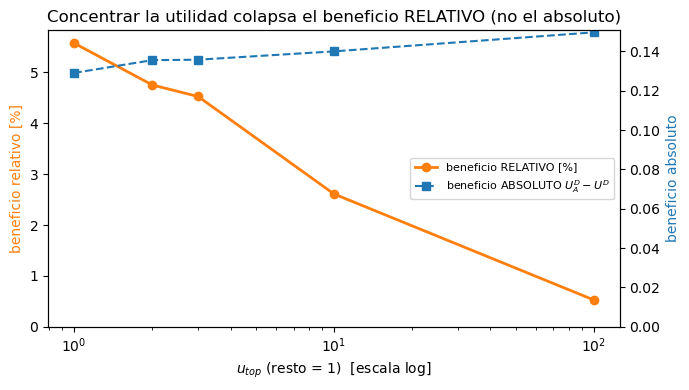

 u_top  rel_mean  abs_mean  frac_zero
   1.0  5.575408  0.129052        0.0
   2.0  4.753266  0.135520        0.0
   3.0  4.527576  0.135757        0.0
  10.0  2.611840  0.139994        0.0
 100.0  0.528447  0.149650        0.0


In [5]:
d = df[df.axis == 'U'].sort_values('u_top')
fig, ax1 = plt.subplots(figsize=(7, 4))
l1 = ax1.plot(d['u_top'], d['rel_mean'], 'o-', color='tab:orange', lw=2,
              label='beneficio RELATIVO [%]')
ax1.set_xscale('log'); ax1.set_xlabel(r'$u_{top}$ (resto = 1)  [escala log]')
ax1.set_ylabel('beneficio relativo [%]', color='tab:orange'); ax1.set_ylim(bottom=0)
ax2 = ax1.twinx()
l2 = ax2.plot(d['u_top'], d['abs_mean'], 's--', color='tab:blue',
              label=r'beneficio ABSOLUTO $U^D_A-U^D$')
ax2.set_ylabel('beneficio absoluto', color='tab:blue'); ax2.set_ylim(bottom=0)
ax1.set_title('Concentrar la utilidad colapsa el beneficio RELATIVO (no el absoluto)')
ax1.legend(l1 + l2, [x.get_label() for x in l1 + l2], loc='center right', fontsize=8)
plt.tight_layout(); plt.show()
print(d[['u_top', 'rel_mean', 'abs_mean', 'frac_zero']].to_string(index=False))

## 4. Bonus: el hueco greedy-vs-óptimo es un fenómeno de primera jugada

Un tercer probe midió el hueco entre el greedy miope augmentado y el óptimo
augmentado. Es casi universal y de tamaño estable (~4.3% relativo, p95 ~9%), con
fracción de ceros ~0: en casi ninguna instancia el greedy alcanza el óptimo. Y es
de **primera jugada**: ~99% de las instancias con hueco divergen ya en el primer
test, donde el greedy elige por recompensa inmediata $P(r{=}0)\cdot\sum u$ y se
sesga a pools chicos o de bajo riesgo, sacrificando información futura. (Números del
workflow; reproducible con `greedy_myopic_counting_expected_utility` vs
`solve_optimal_dapts`.)

## 5. Qué significa para el paper

El borrador dice que la ventaja del conteo "crece con la escala". El barrido lo
precisa: crece con el **horizonte $B$**, satura en $G$, y depende de $N$ menos que
de $B$. Esto sugiere reescribir la figura de crecimiento del paper como una curva
contra $B$ (con el ancla limpia $B=1 \Rightarrow 0$) en vez de contra $N$, que
mezcla tres efectos. Es un mensaje más fuerte y más honesto: el conteo es valioso
exactamente porque hay decisiones futuras que un posterior afilado mejora.

**Salvedades.** El barrido de este notebook usa $n\le 6$ por el muro del DP exacto,
prior $p_i\sim U(0,1)$, $u_i\sim\{1,2,3\}$, y 40 instancias por punto (versión
rápida; `horizon_experiment.py --instances` corre a mayor escala para el clúster).
El ancla $B=1=0$ es una certeza estructural, no estadística; los tamaños de los
spans son empíricos y se afinan con más instancias. El hallazgo se replicó en dos
corridas independientes (el workflow de probes y este barrido).

## Preguntas para Francisco

¿Se puede demostrar que el beneficio del conteo es monótono en $B$ y nulo en $B=1$
en general (no solo empíricamente)? ¿Hay una cota del beneficio en función del
horizonte? ¿La saturación en $G$ tiene una explicación en cerrado (un $G^{*}$ a
partir del cual el conteo no añade información útil)?